In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
import xarray as xr
import matplotlib.pyplot as plt

Found files:
  1984: CHIRPS_Brahmaputra_1984.tif
  1985: CHIRPS_Brahmaputra_1985.tif
  1986: CHIRPS_Brahmaputra_1986.tif
  1987: CHIRPS_Brahmaputra_1987.tif
  1988: CHIRPS_Brahmaputra_1988.tif
  1989: CHIRPS_Brahmaputra_1989.tif
  1990: CHIRPS_Brahmaputra_1990.tif
  1991: CHIRPS_Brahmaputra_1991.tif
  1992: CHIRPS_Brahmaputra_1992.tif
  1993: CHIRPS_Brahmaputra_1993.tif
  1994: CHIRPS_Brahmaputra_1994.tif
  1995: CHIRPS_Brahmaputra_1995.tif
  1996: CHIRPS_Brahmaputra_1996.tif
  1997: CHIRPS_Brahmaputra_1997.tif
  1998: CHIRPS_Brahmaputra_1998.tif
  1999: CHIRPS_Brahmaputra_1999.tif
  2000: CHIRPS_Brahmaputra_2000.tif
  2001: CHIRPS_Brahmaputra_2001.tif
  2002: CHIRPS_Brahmaputra_2002.tif
  2003: CHIRPS_Brahmaputra_2003.tif
  2004: CHIRPS_Brahmaputra_2004.tif
  2005: CHIRPS_Brahmaputra_2005.tif
  2006: CHIRPS_Brahmaputra_2006.tif
  2007: CHIRPS_Brahmaputra_2007.tif
  2008: CHIRPS_Brahmaputra_2008.tif
  2009: CHIRPS_Brahmaputra_2009.tif
  2010: CHIRPS_Brahmaputra_2010.tif
  2011: CHIRPS_

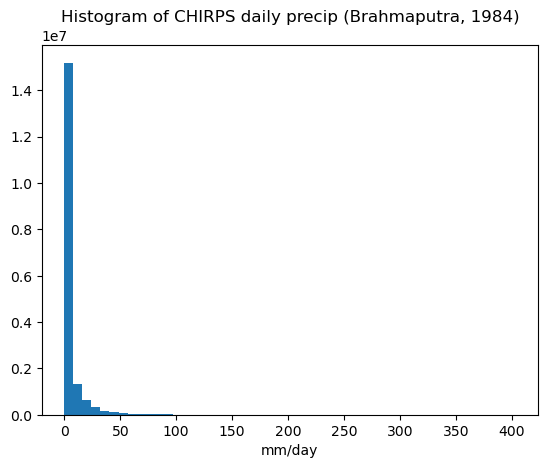

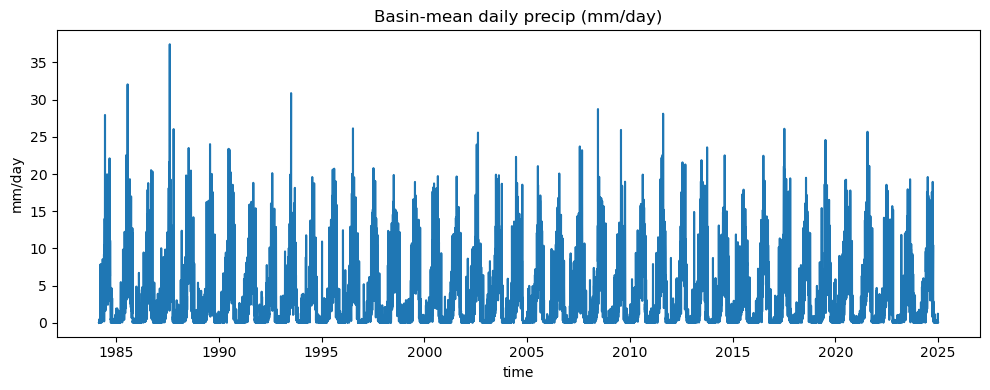

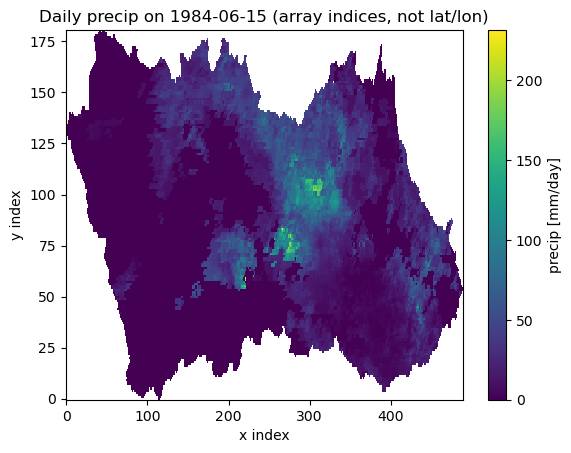


QC5: time series at pixel (y=50, x=50):
<xarray.DataArray 'precip' (time: 5)> Size: 20B
array([nan, nan, nan, nan, nan], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 40B 1984-03-01 1984-03-02 ... 1984-03-05
    y        int64 8B 50
    x        int64 8B 50
Attributes:
    units:    mm/day
    year:     1984
Number of NaN values at pixel (y=50, x=50): 14916

QC6: valid pixel count per day:
  min: 58619 max: 58619


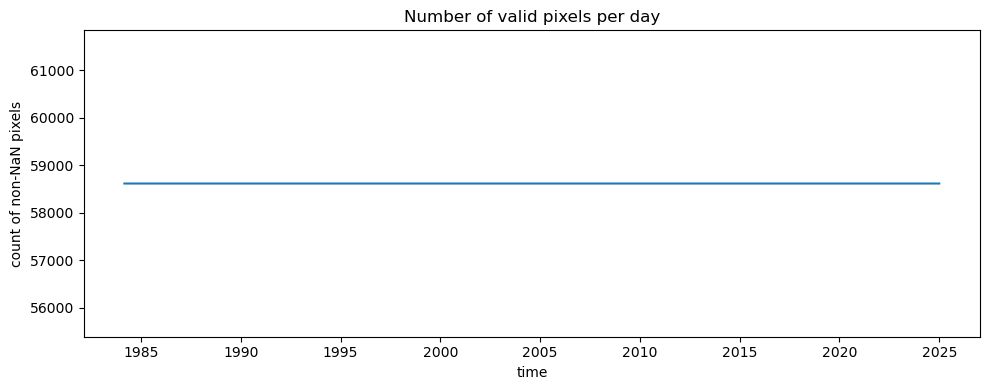


QC7: fraction of valid days per pixel:
  min: 0.0 max: 1.0


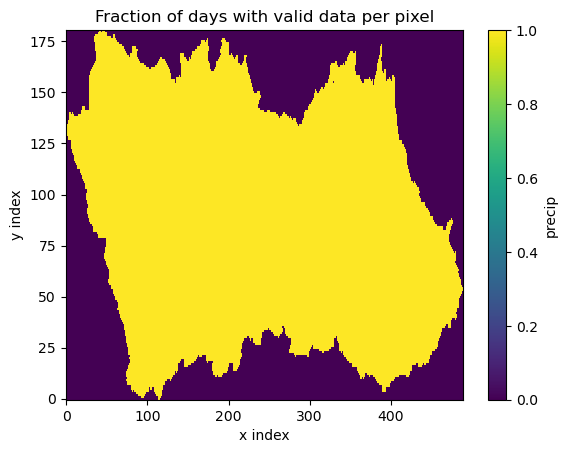

In [9]:
# -----------------------------
# 1. Paths
# -----------------------------

from pathlib import Path
import re

# -----------------------------
# 1. Paths
# -----------------------------

DATA_DIR = Path(
    r"C:\Users\tijme\OneDrive - Delft University of Technology\Machine Learning\CHIRPS_Brahmaputra"
)

# match files like CHIRPS_Brahmaputra_YYYY.tif
pattern = re.compile(r"CHIRPS_Brahmaputra_(\d{4})\.tif")

year_files = []
years = []

for f in DATA_DIR.glob("CHIRPS_Brahmaputra_*.tif"):
    m = pattern.match(f.name)
    if m:
        year_files.append(f)
        years.append(int(m.group(1)))

# sort by year
year_files = [f for _, f in sorted(zip(years, year_files))]
years = sorted(years)

print("Found files:")
for y, f in zip(years, year_files):
    print(f"  {y}: {f.name}")

if not year_files:
    raise FileNotFoundError(
        f"No files matching 'CHIRPS_Brahmaputra_YYYY.tif' found in {DATA_DIR}"
    )

# -----------------------------
# 2. Load yearly files into xarray
# -----------------------------

year_das = []

for tif in year_files:
    year = int(tif.stem.split("_")[-1])   # assumes ..._YYYY.tif
    print(f"\n--- Loading {tif.name} (year {year}) ---")

    with rasterio.open(tif) as ds:
        # ---- georeferencing sanity (QC 8) ----
        print("  CRS:", ds.crs)
        print("  Bounds:", ds.bounds)
        print("  Transform:", ds.transform)
        print("  Pixel size (approx.):", ds.transform.a, "deg in x,",
              ds.transform.e, "deg in y")

        # data: (bands, y, x)
        data = ds.read(masked=True)   # masked array with nodata masked
        data = data.filled(np.nan)    # convert masked to NaN

        band_names = ds.descriptions  # e.g. ('19840301', '19840302', ...)
        print("  shape (bands, y, x):", data.shape)
        print("  number of band names:", len(band_names))

        # parse dates from band names
        time = pd.to_datetime(list(band_names), format="%Y%m%d")
        print("  first date:", time[0], "last date:", time[-1])

        # basic value range check
        print("  value range (ignoring NaN):",
              float(np.nanmin(data)), "to", float(np.nanmax(data)))

        # build DataArray for this year
        y = np.arange(ds.height)
        x = np.arange(ds.width)

    da_year = xr.DataArray(
        data,
        dims=("time", "y", "x"),
        coords={"time": time, "y": y, "x": x},
        name="precip",
        attrs={"units": "mm/day", "year": year},
    )

    year_das.append(da_year)

# combine all years
precip = xr.concat(year_das, dim="time").sortby("time")
print("\nCombined precip DataArray:")
print(precip)
print("Total time steps:", precip.sizes["time"])
print("y size:", precip.sizes["y"], "x size:", precip.sizes["x"])

# -----------------------------
# 3. Quality checks
# -----------------------------

# QC 1: check for non-physical values
print("\nQC1: non-physical values check (first 10 days):")
subset = precip.isel(time=slice(0, 10))
print("  min:", float(subset.min()), "max:", float(subset.max()))
print("  any negative?:", bool((subset < 0).any()))

# QC 2: plot histogram of values for one year (e.g. 1984)
year_1984 = precip.sel(time=slice("1984-03-01", "1984-12-31"))
plt.figure()
year_1984.plot.hist(bins=50)
plt.title("Histogram of CHIRPS daily precip (Brahmaputra, 1984)")
plt.xlabel("mm/day")
plt.show()

# QC 3: basin-mean daily time series (rough sanity)
ts_mean = precip.mean(dim=("y", "x"))  # mean over all pixels
plt.figure(figsize=(10, 4))
ts_mean.plot()
plt.title("Basin-mean daily precip (mm/day)")
plt.ylabel("mm/day")
plt.tight_layout()
plt.show()

# QC 4: pick a single day and plot the spatial field (index space)
sample_date = "1984-06-15"
if sample_date in precip.time.dt.strftime("%Y-%m-%d").values:
    da_day = precip.sel(time=sample_date)
    plt.figure()
    da_day.plot()
    plt.title(f"Daily precip on {sample_date} (array indices, not lat/lon)")
    plt.xlabel("x index")
    plt.ylabel("y index")
    plt.show()
else:
    print(f"{sample_date} not found in time coordinate")

# QC 5: time series at one pixel
y_idx, x_idx = 50, 50
ts_pixel = precip.isel(y=y_idx, x=x_idx)
print(f"\nQC5: time series at pixel (y={y_idx}, x={x_idx}):")
print(ts_pixel.head())

num_nans = int(ts_pixel.isnull().sum())
print(f"Number of NaN values at pixel (y={y_idx}, x={x_idx}): {num_nans}")

# QC 6: mask stability — number of valid pixels per day
valid_per_day = precip.notnull().sum(dim=("y", "x"))
print("\nQC6: valid pixel count per day:")
print("  min:", int(valid_per_day.min().values),
      "max:", int(valid_per_day.max().values))

plt.figure(figsize=(10, 4))
valid_per_day.plot()
plt.title("Number of valid pixels per day")
plt.ylabel("count of non-NaN pixels")
plt.tight_layout()
plt.show()

# If min == max, the mask is perfectly stable; if there is variation,
# some days have slightly more/less missing data.

# QC 7: fraction of valid days per pixel (over full period)
valid_days_per_pixel = precip.notnull().sum(dim="time")
total_days = precip.sizes["time"]
fraction_valid = valid_days_per_pixel / total_days

print("\nQC7: fraction of valid days per pixel:")
print("  min:", float(fraction_valid.min()),
      "max:", float(fraction_valid.max()))

plt.figure()
fraction_valid.plot()
plt.title("Fraction of days with valid data per pixel")
plt.xlabel("x index")
plt.ylabel("y index")
plt.show()

In [10]:
import numpy as np
import pandas as pd

def precipitation_concentration_index(pr, wet_threshold=0.1):
    """
    Precipitation Concentration Index (CI) per year
    Based on Lorenz curve / Gini coefficient of daily precipitation.

    pr : pandas.Series
         daily precipitation (mm/day), DatetimeIndex
    wet_threshold : float
         threshold to define wet days (mm/day)

    Returns
    -------
    pandas.Series with yearly CI values (0–1)
    """
    pr = pr.dropna()
    results = {}

    for year, s in pr.groupby(pr.index.year):
        wet = s[s > wet_threshold].values

        if wet.size < 2 or wet.sum() == 0:
            results[year] = np.nan
            continue

        x = np.sort(wet)
        n = len(x)
        cumx = np.cumsum(x)

        # Lorenz curve
        p = np.arange(1, n + 1) / n
        L = cumx / cumx[-1]

        # Gini coefficient
        auc = np.trapz(np.r_[0, L], np.r_[0, p])
        gini = 1 - 2 * auc

        results[year] = gini

    return pd.Series(results, name="CI")


In [17]:
pr_series = ts_mean.to_pandas()  # DatetimeIndex, mm/day
ci_yearly = precipitation_concentration_index(pr_series)

#print(ci_yearly)
ci_norm = (ci_yearly - ci_yearly.min()) / (ci_yearly.max() - ci_yearly.min())
ci_norm.name = "CI_normalized"

print(ci_norm)
ci_norm.to_csv("ci_vs_total_precip.csv", index=True)

1984    0.125970
1985    0.557738
1986    0.650587
1987    0.703349
1988    0.535189
1989    0.542304
1990    0.547545
1991    0.355884
1992    0.571748
1993    0.116124
1994    0.506497
1995    0.612804
1996    0.624640
1997    0.730154
1998    0.356040
1999    0.352199
2000    0.602149
2001    0.000000
2002    0.307631
2003    0.263090
2004    0.234332
2005    0.412586
2006    0.367044
2007    0.312545
2008    0.645722
2009    0.748108
2010    0.433696
2011    0.792816
2012    0.587015
2013    0.722156
2014    0.598598
2015    0.634614
2016    0.399203
2017    0.899432
2018    1.000000
2019    0.902536
2020    0.444585
2021    0.636293
2022    0.542679
2023    0.899994
2024    0.690803
Name: CI_normalized, dtype: float64


C:\Users\tijme\AppData\Local\Temp\ipykernel_1596\803771855.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(np.r_[0, L], np.r_[0, p])


C:\Users\tijme\AppData\Local\Temp\ipykernel_1596\1314358419.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_total = pr_series.resample("Y").sum()


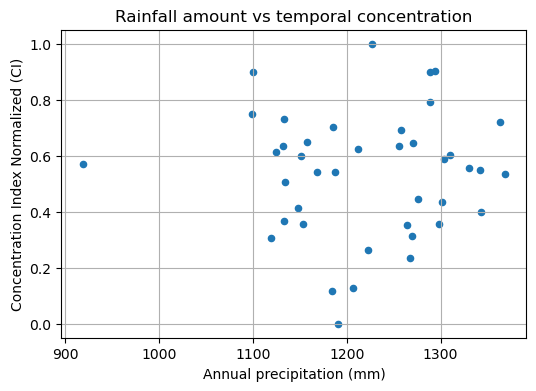

In [15]:
annual_total = pr_series.resample("Y").sum()
annual_total.index = annual_total.index.year

df = pd.DataFrame({
    "Total_mm": annual_total,
    "CI": ci_norm
})

df.plot.scatter(x="Total_mm", y="CI", figsize=(6,4))
plt.xlabel("Annual precipitation (mm)")
plt.ylabel("Concentration Index Normalized (CI)")
plt.title("Rainfall amount vs temporal concentration")
plt.grid(True)
plt.show()